              **Breast Cancer Classification Neural Networks Project**

A Neural Network is a Machine Learning Model inspired by how the human brain works. It is designed to recognize the patterns, learn from the data and make predictions.

**Basic Neurons**
Just like the brain has neurons, a neural network has artificial neurons conneted together. They are arranged in layers:

1. Input Layer: Takes the datain form of numbers, images and text.
2. Gidden Layers : Do calculations andlearn patterns.
3. Output layer : Gives the final predictions and results.

**Step by Step Working**

1. Data enters the network.
2. Each neuron multiplies the inputs by weight.  
3. Adds the bias  
4. Passes thorough an activation function

5. output is produced.
6. Errors are calculated.
7. Weights are adjusted by Back Propagation.

This process gets repested many times and hence this is called as training.

**Back Propagation**

Back Propagation refers to a technique in the neural networks which is a fundamentsl algorithm used to train the artificial neural networks by calculating the gradient of the loss of the functions with respect to the loss of the networks' weights.

It calculates from the output layer moving backward, enabling efficient updates to minimize errors and improve accuracy.

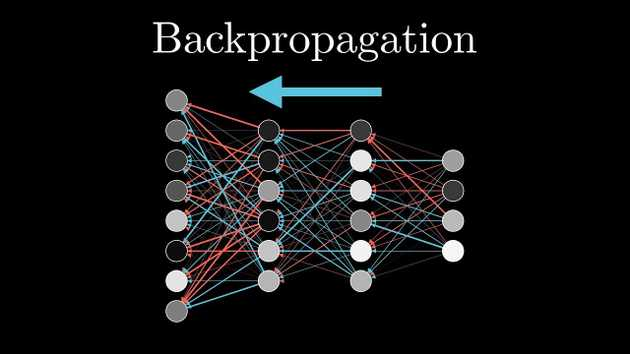

**Types of Neural Networks**

The common types of neural networks are mainly:

1.ANN (Artificial neural Network) : Basic Neural network

2 CNN (Convolutional Neural network): It is mainly used for image classification.

3.RNN (Recurral neural Network) : It is atype of neural network used for sequences and time data.  

4.LSTM (Long Short Term Memory) : It is an advanced memory used for long memory.

**Neural Network used for Breast Cancer Classification Project**

The type of neural network used for the Breast Cancer Classification Project is the Artificial Neural Network.  

An Artificial neural Network is a type of ML inspired by the way, the human brain works. It is designed to learn patterns from the data and make decisionslike the classification, prediction and recognition.

**Basic Structure of ANN**

An ANN has mainly 3 typesof layers:

1.Input Layer: It receives the data and each neuron is one feature.

2.Hidden Layers : It performs the calculations and learnss the patterns from the data ans can form multiple layers.

3.Output Layer gives the final prediction.

In this project, the predition has been made on 30 features divided into 3 categories.

Category 1 : Mean of measurements
1. mean radius
2. mean texture
3. mean perimeter
4. mean area
5. mean smoothness
6. mean compactness
7. mean concavity
8. mean concave points
9. mean symmetry
10. mean fractal dimension  

Category 2 : Standard Error showws variation in errors

11. radius_error
12. texture_error
13. perimeter_error
14. area_error
15. smoothness_error
16. compactness_error
17. concavity_error
18. concave_points_error
19. symmetry_error
20. fractal_dimension_error


Category 3: Worst Features

1 worst radius

2 worst texture

3 worst perimeter

4 worst area

5 worst smoothness

6 worst compactness

7 worst concavity

8 worst concave points

9.worst symmetry

10.worst fractal dimension

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

In [12]:
# Loading the dataset

data = load_breast_cancer()

In [13]:
x= pd.DataFrame(data.data, columns=data.feature_names)
x

# here there are 30 features, based on which the dataset has been made

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [14]:
y = pd.DataFrame(data.target)
y

# Here 0 means that the tumor is malignant and 1 means that a tumor is benign

,0
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [15]:
print("Features Shape: ", x.shape)
print("Target Shape: ", y.shape)

Features Shape:  (569, 30)
Target Shape:  (569, 1)


In [16]:
# Bow, we will be performing the train, test and the split as it is the best
from sklearn.model_selection import train_test_split

x_train,x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [17]:
x_train
# Data on which the model is trained

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
68,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,0.04375,0.2111,0.08046,...,10.310,22.65,65.50,324.7,0.14820,0.43650,1.25200,0.17500,0.4228,0.11750
181,21.090,26.57,142.70,1311.0,0.11410,0.28320,0.24870,0.14960,0.2395,0.07398,...,26.680,33.48,176.50,2089.0,0.14910,0.75840,0.67800,0.29030,0.4098,0.12840
63,9.173,13.86,59.20,260.9,0.07721,0.08751,0.05988,0.02180,0.2341,0.06963,...,10.010,19.23,65.59,310.1,0.09836,0.16780,0.13970,0.05087,0.3282,0.08490
248,10.650,25.22,68.01,347.0,0.09657,0.07234,0.02379,0.01615,0.1897,0.06329,...,12.250,35.19,77.98,455.7,0.14990,0.13980,0.11250,0.06136,0.3409,0.08147
60,10.170,14.88,64.55,311.9,0.11340,0.08061,0.01084,0.01290,0.2743,0.06960,...,11.020,17.45,69.86,368.6,0.12750,0.09866,0.02168,0.02579,0.3557,0.08020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,8.888,14.64,58.79,244.0,0.09783,0.15310,0.08606,0.02872,0.1902,0.08980,...,9.733,15.67,62.56,284.4,0.12070,0.24360,0.14340,0.04786,0.2254,0.10840
106,11.640,18.33,75.17,412.5,0.11420,0.10170,0.07070,0.03485,0.1801,0.06520,...,13.140,29.26,85.51,521.7,0.16880,0.26600,0.28730,0.12180,0.2806,0.09097
270,14.290,16.82,90.30,632.6,0.06429,0.02675,0.00725,0.00625,0.1508,0.05376,...,14.910,20.65,94.44,684.6,0.08567,0.05036,0.03866,0.03333,0.2458,0.06120
435,13.980,19.62,91.12,599.5,0.10600,0.11330,0.11260,0.06463,0.1669,0.06544,...,17.040,30.80,113.90,869.3,0.16130,0.35680,0.40690,0.18270,0.3179,0.10550


In [18]:
x_test
# Data on which the model is tested

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
204,12.47,18.60,81.09,481.9,0.09965,0.10580,0.08005,0.03821,0.1925,0.06373,...,14.97,24.64,96.05,677.9,0.1426,0.2378,0.2671,0.10150,0.3014,0.08750
70,18.94,21.31,123.60,1130.0,0.09009,0.10290,0.10800,0.07951,0.1582,0.05461,...,24.86,26.58,165.90,1866.0,0.1193,0.2336,0.2687,0.17890,0.2551,0.06589
131,15.46,19.48,101.70,748.9,0.10920,0.12230,0.14660,0.08087,0.1931,0.05796,...,19.26,26.00,124.90,1156.0,0.1546,0.2394,0.3791,0.15140,0.2837,0.08019
431,12.40,17.68,81.47,467.8,0.10540,0.13160,0.07741,0.02799,0.1811,0.07102,...,12.88,22.91,89.61,515.8,0.1450,0.2629,0.2403,0.07370,0.2556,0.09359
540,11.54,14.44,74.65,402.9,0.09984,0.11200,0.06737,0.02594,0.1818,0.06782,...,12.26,19.68,78.78,457.8,0.1345,0.2118,0.1797,0.06918,0.2329,0.08134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,14.64,16.85,94.21,666.0,0.08641,0.06698,0.05192,0.02791,0.1409,0.05355,...,16.46,25.44,106.00,831.0,0.1142,0.2070,0.2437,0.07828,0.2455,0.06596
75,16.07,19.65,104.10,817.7,0.09168,0.08424,0.09769,0.06638,0.1798,0.05391,...,19.77,24.56,128.80,1223.0,0.1500,0.2045,0.2829,0.15200,0.2650,0.06387
249,11.52,14.93,73.87,406.3,0.10130,0.07808,0.04328,0.02929,0.1883,0.06168,...,12.65,21.19,80.88,491.8,0.1389,0.1582,0.1804,0.09608,0.2664,0.07809
238,14.22,27.85,92.55,623.9,0.08223,0.10390,0.11030,0.04408,0.1342,0.06129,...,15.75,40.54,102.50,764.0,0.1081,0.2426,0.3064,0.08219,0.1890,0.07796


In [19]:
y_train
# Data on which the model is trained

,0
68,1
181,0
63,1
248,1
60,1
...,...
71,1
106,1
270,1
435,0


In [20]:
y_test
# Data on which the model is tested

,0
204,1
70,0
131,0
431,1
540,1
...,...
486,1
75,0
249,1
238,1


In [22]:
# Now, we will be performing the feature scaling as because the scaled data works better on the neural networks algorithm

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [26]:
# Now, we will be building the neural network model for performing the classification

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

In [30]:
model = Sequential()

model.add(Dense(16, activation = 'relu', input_shape = (30,)))
# This is the input layer and the hidden layer 1

model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<Sequential name=sequential_1, built=True>

In [33]:
# Now, we will be adding the hidden layer 2
model.add(Dense(8, activation = 'relu'))
model

<Sequential name=sequential_1, built=True>

In [34]:
model.add(Dense(1, activation = 'sigmoid'))
model

<Sequential name=sequential_1, built=True>

In [40]:
# Now, we will be compiling the model for the further preprocessing

model.compile(optimizer = 'adam', loss = 'crossentropy', metrics = ['accuracy'])


In [41]:
# training the model

history = model.fit(x_train, y_train, epochs = 50, batch_size = 16, validation_split = 0.2, verbose = 1)
history

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4447 - loss: 0.6173 - val_accuracy: 0.8352 - val_loss: 0.5554
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8963 - loss: 0.5059 - val_accuracy: 0.9011 - val_loss: 0.4801
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9725 - loss: 0.4251 - val_accuracy: 0.9231 - val_loss: 0.3852
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9745 - loss: 0.3202 - val_accuracy: 0.9341 - val_loss: 0.2779
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9659 - loss: 0.2179 - val_accuracy: 0.9341 - val_loss: 0.1901
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9702 - loss: 0.1299 - val_accuracy: 0.9451 - val_loss: 0.1502
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9861 - loss: 0.0797 - val_accuracy: 0.9451 - val_loss: 0.1339
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9915 - loss: 0.0602 - val_accuracy: 0.9451 - v

Now, we will be discussing all the features one by one.  

1.Epoch: One epoch means one complete pass through the entire training dataset.  
Suppose, if we have 1000 samples, then 1 epoch means that the model sees all the 1000 samples and 50 epochs is quite accurate for making the predictions.  

2.batch-size =16
Instead of training on all the data once, we slit the data into groups. So the model learns in small steps. It is used as it speeds up the learning and improoves the accuracy.

3.validation_split = 0.2
20% of the training data is used for the validation. It checks if a model is learning properly and it is used for detecting overfitting.  

4.verbose = 1
This basically shows that how the training progress is controlled.


**Need for multiple epochs**

We need multiple epochs as because a neural network learns by using the radual weight updates.  

Each epoch:

1.Makes prediction

2.Calculates the error

3.Adjusts the weight

4.It improves the accuracy

This process is called as the Backpropagation.

Basically there is a simple analogy for the Neural Networks. Learning ANN is like learning for exams.  

1.Epoch - Learning for exams

2.Batch - Studying chapter wise

3.Validation - Taking mock tests

In [42]:
# Evaluating the model

loss, accuracy = model.evaluate(x_test,y_test)
loss, accuracy

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9794 - loss: 0.0852


(0.05789331719279289, 0.9824561476707458)

In [44]:
print("Test Accuracy: ",accuracy)

Test Accuracy:  0.9824561476707458


In [48]:
# Now, we will be prediction on test set

y_pred = model.predict(x_test)
y_pred= (y_pred > 0.5).astype(int)
y_pred

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


array([[1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
    

In [52]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Printing the accuracy score
print("Accuracy Score: ", accuracy_score(y_test, y_pred))

# The accuracy score is around 98 percent

Accuracy Score:  0.9824561403508771


In [59]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n=================Classification Report================\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[42  1]
 [ 1 70]]

=================Classification Report================
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



**Visualixation Reports**

Now, we will be plotting the visualization reports for the easy understanding of the plots.

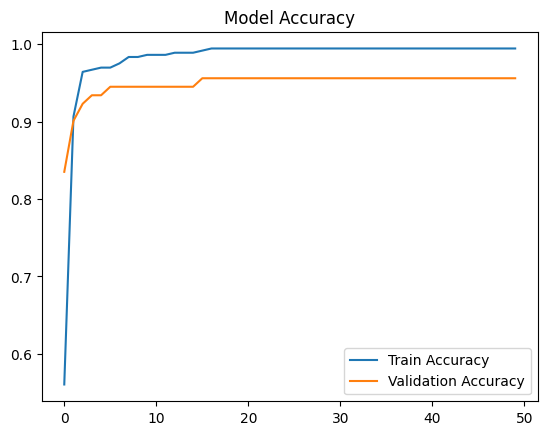

In [60]:
# Plotting the traning performance

plt.plot(history.history['accuracy'], label = "Train Accuracy")
plt.plot(history.history['val_accuracy'], label = "Validation Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.show()

**Graph Explanation**

X-axis tells about the epochs and y-axis tells us how well the model is performing.  

Training accuracy tells ho well the model performs on training data.

Validation Accuracy Score tells the performance on unseen data.

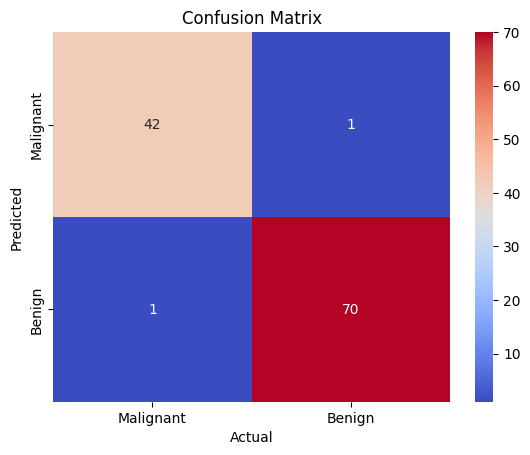

In [61]:
# Plotting of the confusion matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'coolwarm',
            xticklabels = ["Malignant", "Benign"],
            yticklabels = ["Malignant", "Benign"])

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Confusion Matrix")
plt.show()

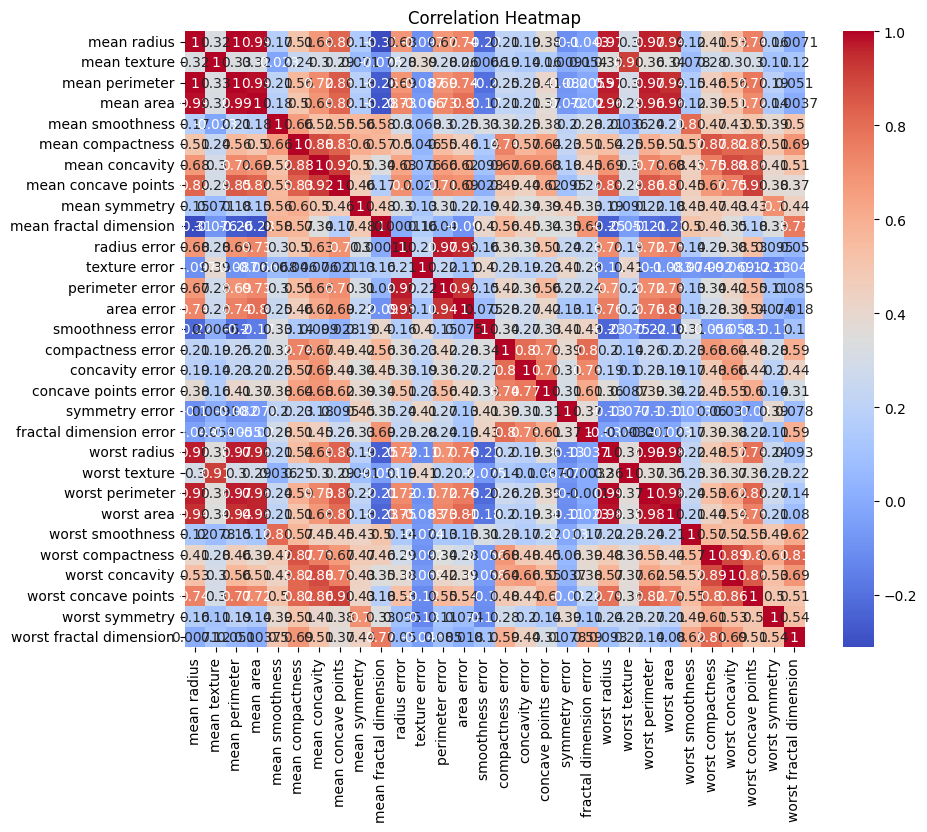

In [69]:
# Plotting of the Heatmap
plt.figure(figsize = (10,8))
sns.heatmap(x.corr(numeric_only = True), annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Prediction on New Data**

In [71]:
# Here all the 30 features have been used.
new_patient = np.array([
    14.5, 20.3, 95.1, 650.2, 0.10,
    0.18, 0.20, 0.09, 0.18, 0.06,
    0.25, 1.30, 2.50, 30.0, 0.01,
    0.04, 0.05, 0.02, 0.02, 0.003,
    16.5, 25.1, 110.0, 800.5, 0.14,
    0.30, 0.32, 0.15, 0.28, 0.09
]).reshape(1, -1)

new_patient = sc.transform(new_patient)

prediction = model.predict(new_patient)

prediction[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


array([0.], dtype=float32)

In [72]:
if prediction == 1:
  print("Prediction: Benign")

else:
  print("Prediction: Malignant")

Prediction: Malignant
